In [5]:
import pandas as pd

df = pd.read_csv('../data/raw/ecommerce_clothing_complaints.csv')
print(df.shape)
print(df.head())

(1000, 7)
                                      complaint_text  complaint_type language  \
0  Saree color was red online but received pink, ...  color_mismatch  english   
1    Fabric is rough and fake, returning immediately     fake_fabric  english   
2  Ordered XL kurta but received M size, totally ...      wrong_size  english   
3  Ordered XL kurta but received M size, totally ...      wrong_size  english   
4  Saree color was red online but received pink, ...  color_mismatch  english   

   anger_score  days_pending  repeat_count  escalation_label  
0         0.57             9             4                 1  
1         0.58             1             1                 0  
2         0.54             7             1                 0  
3         0.68             4             3                 1  
4         0.79             9             3                 1  


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['complaint_type'])
print(df[['complaint_type', 'category_encoded']].drop_duplicates())

        complaint_type  category_encoded
0       color_mismatch                 0
1          fake_fabric                 1
2           wrong_size                 4
5    return_not_picked                 3
8  refund_not_credited                 2


In [7]:
X = df[['anger_score', 'days_pending', 'repeat_count', 'category_encoded']]
y = df['escalation_label']

print("Features shape:", X.shape)
print("Label distribution:")
print(y.value_counts())

Features shape: (1000, 4)
Label distribution:
escalation_label
1    681
0    319
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


In [9]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X_train, y_train)
print("Training done")

Training done


In [10]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print()
print(classification_report(y_test, predictions))

Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        68
           1       1.00      1.00      1.00       132

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [11]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/escalation_model.pkl')
joblib.dump(le, 'models/label_encoder.pkl')
print("Both files saved successfully")

Both files saved successfully


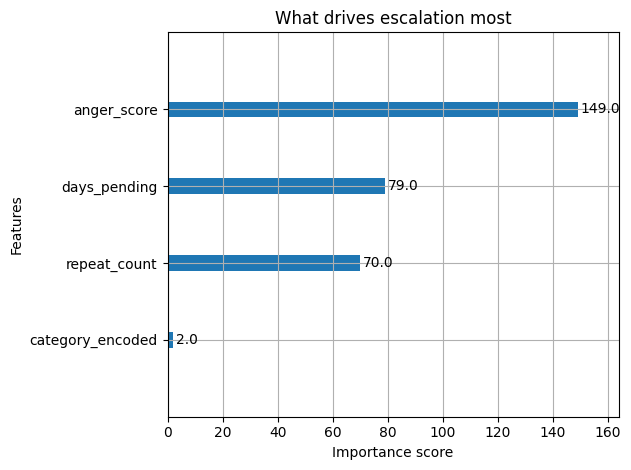

In [12]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.title("What drives escalation most")
plt.tight_layout()
plt.savefig('models/feature_importance.png')
plt.show()

In [13]:
def predict_escalation(anger_score, days_pending, repeat_count, complaint_type):
    model = joblib.load('models/escalation_model.pkl')
    le = joblib.load('models/label_encoder.pkl')
    
    category_encoded = le.transform([complaint_type])[0]
    features = [[anger_score, days_pending, repeat_count, category_encoded]]
    risk_score = model.predict_proba(features)[:, 1][0]
    
    if risk_score >= 0.75:
        level = "Critical"
    elif risk_score >= 0.50:
        level = "High"
    elif risk_score >= 0.30:
        level = "Medium"
    else:
        level = "Low"
    
    return round(risk_score * 100, 1), level

# Test with all 5 complaint types
print(predict_escalation(0.95, 20, 3, 'refund_not_credited'))
print(predict_escalation(0.2, 1, 1, 'wrong_size'))
print(predict_escalation(0.85, 15, 4, 'return_not_picked'))
print(predict_escalation(0.5, 5, 2, 'color_mismatch'))
print(predict_escalation(0.75, 10, 3, 'fake_fabric'))

(np.float32(99.9), 'Critical')
(np.float32(0.3), 'Low')
(np.float32(99.9), 'Critical')
(np.float32(0.3), 'Low')
(np.float32(99.8), 'Critical')
